✅ All libraries imported successfully!
✅ Dataset loaded!
FIRST 5 ROWS
      name  math  science  english  history  pe  attendance_pct  \
0    Alice    88       92       76       80  95              92   
1      Bob    42       55       48       50  60              65   
2  Charlie    75       70       80       68  88              85   
3    Diana    95       98       91       89  97              98   
4      Eve    38       42       50       45  55              58   

   study_hours_per_day  passed  
0                  4.5       1  
1                  1.2       0  
2                  3.0       1  
3                  6.0       1  
4                  0.8       0  
SHAPE (rows × columns)
Rows: 15,  Columns: 9
DATA TYPES OF EACH COLUMN
name                       str
math                     int64
science                  int64
english                  int64
history                  int64
pe                       int64
attendance_pct           int64
study_hours_per_day    float64
passed    

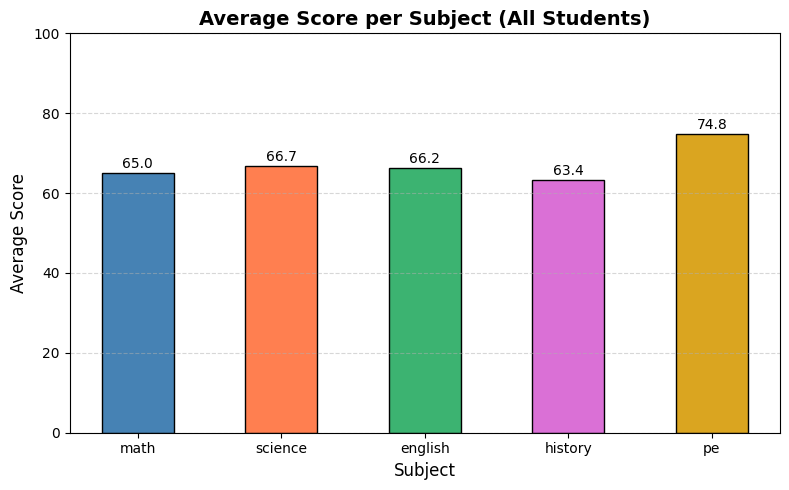

✅ plot1_bar.png saved.


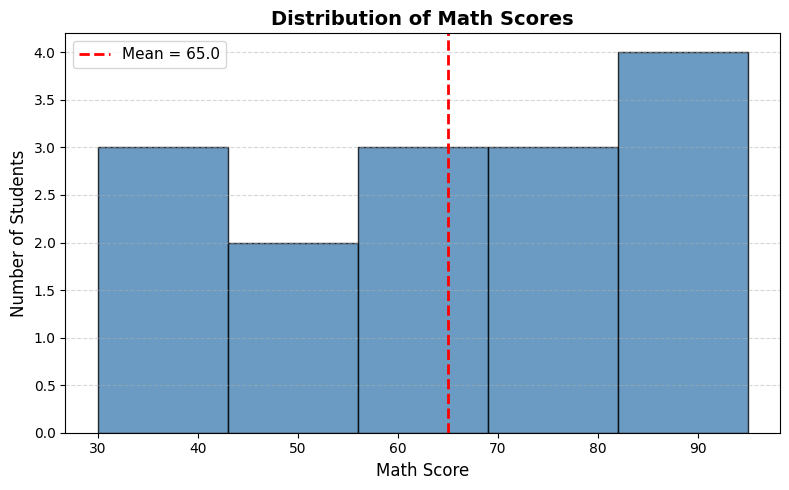

✅ plot2_histogram.png saved.


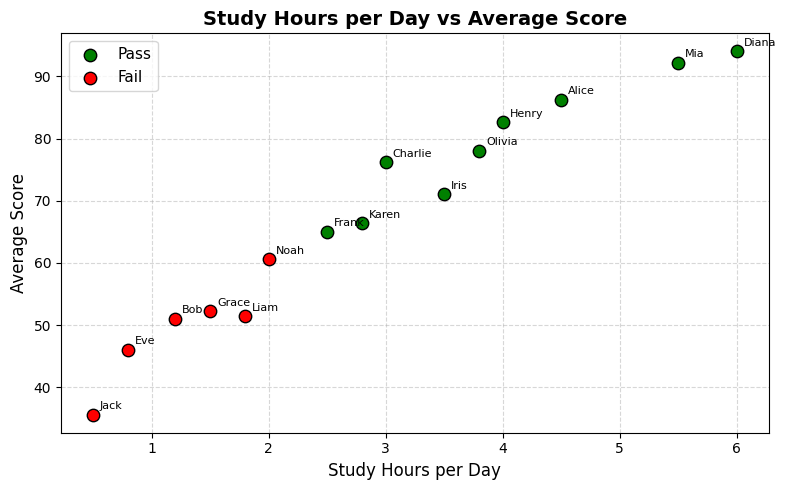

✅ plot3_scatter.png saved.


C:\Users\vobalap\AppData\Local\Temp\ipykernel_2904\3104911758.py:192: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot([pass_attendance, fail_attendance],


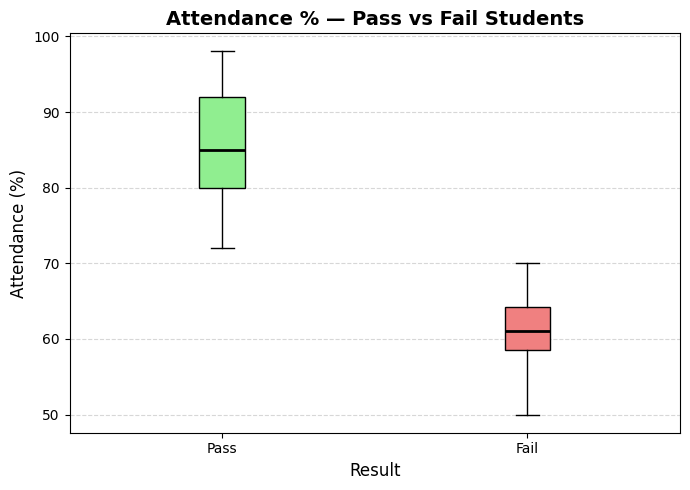

✅ plot4_boxplot.png saved.


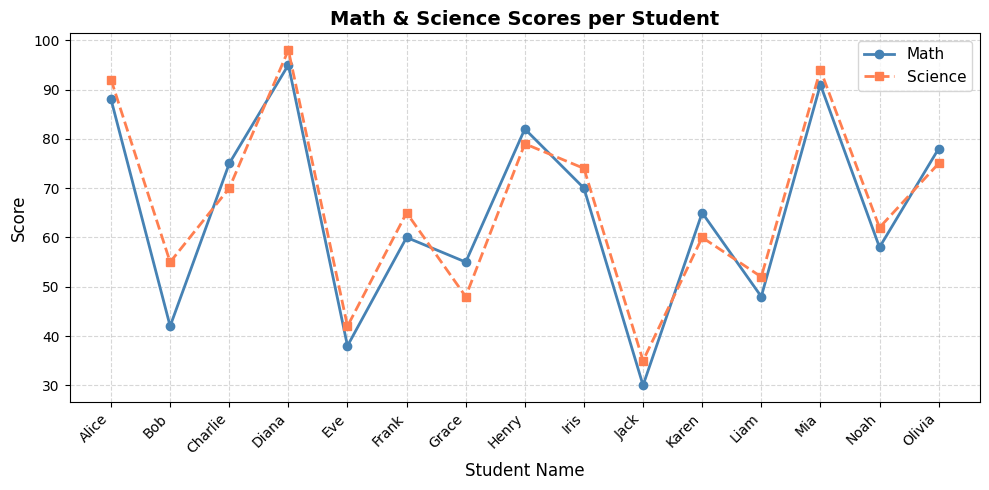

✅ plot5_line.png saved.


In [15]:
from turtle import towards

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
print("✅ All libraries imported successfully!")
# ============================================================
# TASK 1 — Data Exploration with Pandas
# ============================================================

# ----------------------------------------------------------
# 1.1  Load the dataset
# ----------------------------------------------------------
# Make sure students.csv is in the same folder as this notebook.
df = pd.read_csv("students.csv")
print("✅ Dataset loaded!")

# ----------------------------------------------------------
# 1.2  First 5 rows
# ----------------------------------------------------------
print("=" * 50)
print("FIRST 5 ROWS")
print("=" * 50)
print(df.head())

# ----------------------------------------------------------
# 1.3  Shape and data types
# ----------------------------------------------------------
print("" + "=" * 50)
print("SHAPE (rows × columns)")
print("=" * 50)
print(f"Rows: {df.shape[0]},  Columns: {df.shape[1]}")

print("" + "=" * 50)
print("DATA TYPES OF EACH COLUMN")
print("=" * 50)
print(df.dtypes)

# ----------------------------------------------------------
# 1.4  Summary statistics
# ----------------------------------------------------------
print("" + "=" * 50)
print("SUMMARY STATISTICS (mean, min, max, std)")
print("=" * 50)
print(df.describe().round(2))

# ----------------------------------------------------------
# 1.5  Count of students who passed vs failed
# ----------------------------------------------------------
print("" + "=" * 50)
print("PASS / FAIL COUNT")
print("=" * 50)
counts = df['passed'].value_counts()
print(f"Passed (1): {counts[1]} students")
print(f"Failed (0): {counts[0]} students")

# ----------------------------------------------------------
# 1.6  Average score per subject for Pass vs Fail groups
# ----------------------------------------------------------
subject_cols = ['math', 'science', 'english', 'history', 'pe']

pass_avg = df[df['passed'] == 1][subject_cols].mean().round(2)
fail_avg = df[df['passed'] == 0][subject_cols].mean().round(2)

print("" + "=" * 50)
print("AVERAGE SCORE PER SUBJECT — PASSING STUDENTS")
print("=" * 50)
print(pass_avg.to_string())

print("" + "=" * 50)
print("AVERAGE SCORE PER SUBJECT — FAILING STUDENTS")
print("=" * 50)
print(fail_avg.to_string())

# ----------------------------------------------------------
# 1.7  Student with the highest overall average
# ----------------------------------------------------------
# .mean(axis=1) calculates the average across columns for each row
df['temp_avg'] = df[subject_cols].mean(axis=1)
best_student = df.loc[df['temp_avg'].idxmax()]

print("" + "=" * 50)
print("STUDENT WITH HIGHEST OVERALL AVERAGE")
print("=" * 50)
print(f"Name   : {best_student['name']}")
print(f"Average: {best_student['temp_avg']:.2f}")

# Remove the temporary column so it doesn't affect later tasks
df.drop(columns=['temp_avg'], inplace=True)
# ============================================================
# TASK 2 — Data Visualization with Matplotlib
# ============================================================

# Add the avg_score column (used in several plots below)
subject_cols = ['math', 'science', 'english', 'history', 'pe']
df['avg_score'] = df[subject_cols].mean(axis=1)
print("✅ avg_score column added to DataFrame.")

# ----------------------------------------------------------
# Plot 1 — Bar Chart: Average score per subject
# ----------------------------------------------------------
subject_means = df[subject_cols].mean()  # one mean value per subject

fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.bar(subject_means.index, subject_means.values,
              color=['steelblue', 'coral', 'mediumseagreen', 'orchid', 'goldenrod'],
              edgecolor='black', width=0.5)

# Add the value on top of each bar
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, height + 0.5,
            f'{height:.1f}', ha='center', va='bottom', fontsize=10)

ax.set_title('Average Score per Subject (All Students)', fontsize=14, fontweight='bold')
ax.set_xlabel('Subject', fontsize=12)
ax.set_ylabel('Average Score', fontsize=12)
ax.set_ylim(0, 100)
ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('plot1_bar.png', dpi=150)
plt.show()
print("✅ plot1_bar.png saved.")

# ----------------------------------------------------------
# Plot 2 — Histogram: Distribution of math scores
# ----------------------------------------------------------
mean_math = df['math'].mean()

fig, ax = plt.subplots(figsize=(8, 5))

ax.hist(df['math'], bins=5, color='steelblue', edgecolor='black', alpha=0.8)

# Vertical dashed line at the mean
ax.axvline(mean_math, color='red', linestyle='--', linewidth=2,
           label=f'Mean = {mean_math:.1f}')

ax.set_title('Distribution of Math Scores', fontsize=14, fontweight='bold')
ax.set_xlabel('Math Score', fontsize=12)
ax.set_ylabel('Number of Students', fontsize=12)
ax.legend(fontsize=11)
ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('plot2_histogram.png', dpi=150)
plt.show()
print("✅ plot2_histogram.png saved.")
# ----------------------------------------------------------
# Plot 3 — Scatter Plot: Study hours vs Average score
# ----------------------------------------------------------
pass_df = df[df['passed'] == 1]
fail_df = df[df['passed'] == 0]

fig, ax = plt.subplots(figsize=(8, 5))

ax.scatter(pass_df['study_hours_per_day'], pass_df['avg_score'],
           color='green', label='Pass', s=80, edgecolors='black', zorder=3)
ax.scatter(fail_df['study_hours_per_day'], fail_df['avg_score'],
           color='red', label='Fail', s=80, edgecolors='black', zorder=3)

# Label each point with the student's name
for _, row in df.iterrows():
    ax.annotate(row['name'],
                (row['study_hours_per_day'], row['avg_score']),
                textcoords="offset points", xytext=(5, 4), fontsize=8)

ax.set_title('Study Hours per Day vs Average Score', fontsize=14, fontweight='bold')
ax.set_xlabel('Study Hours per Day', fontsize=12)
ax.set_ylabel('Average Score', fontsize=12)
ax.legend(fontsize=11)
ax.grid(linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('plot3_scatter.png', dpi=150)
plt.show()
print("✅ plot3_scatter.png saved.")

# ----------------------------------------------------------
# Plot 4 — Box Plot: Attendance % for Pass vs Fail
# ----------------------------------------------------------
pass_attendance = df[df['passed'] == 1]['attendance_pct'].tolist()
fail_attendance = df[df['passed'] == 0]['attendance_pct'].tolist()

fig, ax = plt.subplots(figsize=(7, 5))

bp = ax.boxplot([pass_attendance, fail_attendance],
                labels=['Pass', 'Fail'],
                patch_artist=True,
                medianprops=dict(color='black', linewidth=2))

# Colour the two boxes differently
bp['boxes'][0].set_facecolor('lightgreen')
bp['boxes'][1].set_facecolor('lightcoral')

ax.set_title('Attendance % — Pass vs Fail Students', fontsize=14, fontweight='bold')
ax.set_xlabel('Result', fontsize=12)
ax.set_ylabel('Attendance (%)', fontsize=12)
ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('plot4_boxplot.png', dpi=150)
plt.show()
print("✅ plot4_boxplot.png saved.")

# ----------------------------------------------------------
# Plot 5 — Line Plot: Math & Science scores per student
# ----------------------------------------------------------
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(df['name'], df['math'],
        marker='o', linestyle='-', color='steelblue', label='Math', linewidth=2)
ax.plot(df['name'], df['science'],
        marker='s', linestyle='--', color='coral', label='Science', linewidth=2)

# Rotate x-axis labels so names don't overlap
plt.xticks(rotation=45, ha='right')

ax.set_title('Math & Science Scores per Student', fontsize=14, fontweight='bold')
ax.set_xlabel('Student Name', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.legend(fontsize=11)
ax.grid(linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('plot5_line.png', dpi=150)
plt.show()
print("✅ plot5_line.png saved.")





C:\Users\vobalap\AppData\Local\Temp\ipykernel_2904\1489347526.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='result_label', y='math', ax=ax1,
C:\Users\vobalap\AppData\Local\Temp\ipykernel_2904\1489347526.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='result_label', y='science', ax=ax2,


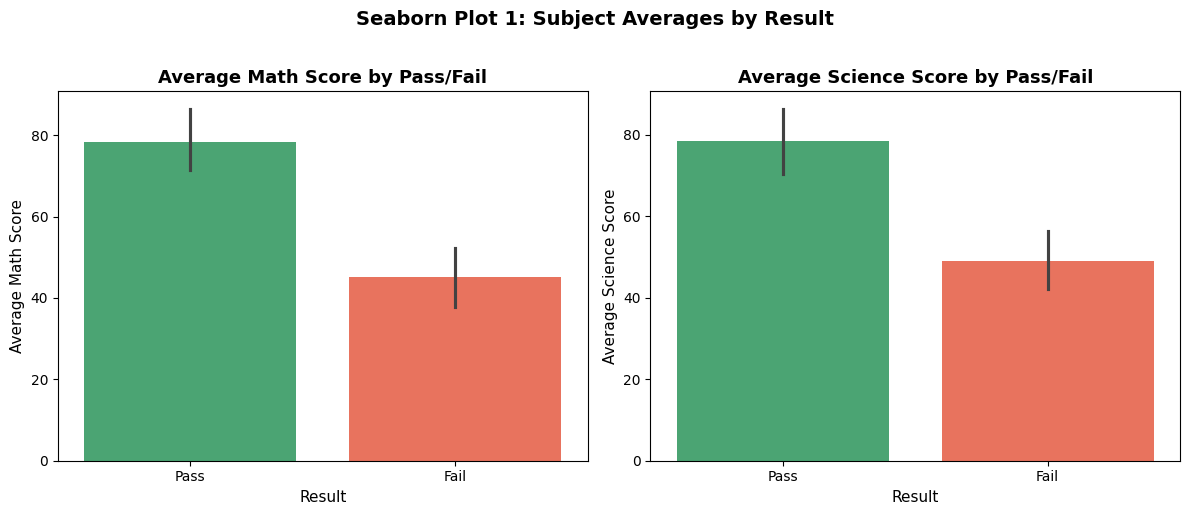

seaborn_plot1_barplot.png saved.


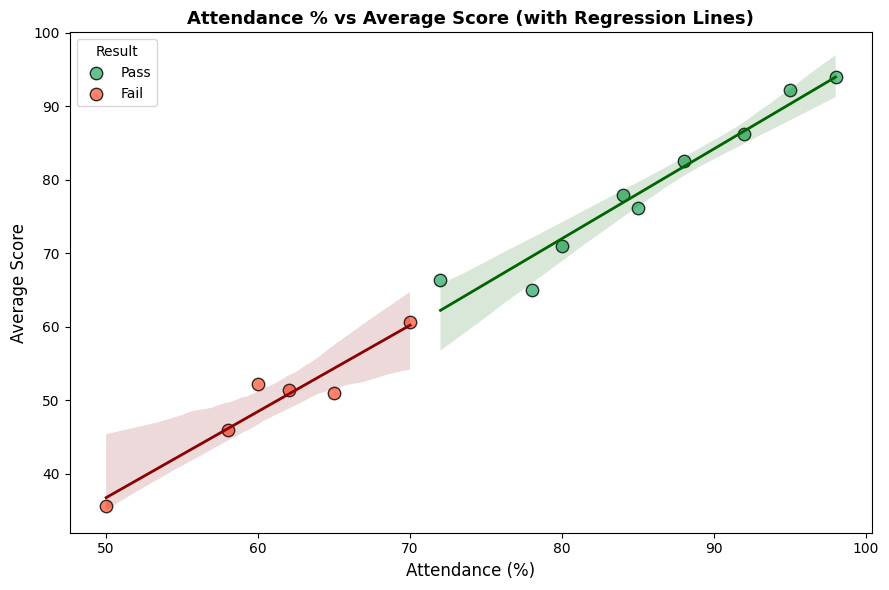

seaborn_plot2_regplot.png saved.


In [21]:
# ============================================================
# TASK 3 — DATA VISUALIZATION WITH SEABORN
# ============================================================

# ── KEY FIX: Map 0/1 to string labels BEFORE using in Seaborn ─
# Newer versions of Seaborn convert numeric x-axis values to
# strings internally ('0', '1'). If your palette keys are integers
# (0, 1), Seaborn cannot find them and throws a ValueError.
# Solution: create a new column with actual string values 'Pass'/'Fail'
# and use THAT as the x-axis, with matching string palette keys.
df['result_label'] = df['passed'].map({1: 'Pass', 0: 'Fail'})

# ── Seaborn Plot 1: Bar plots — Math & Science avg by Pass/Fail ─
# Shows: do passing students score higher in math and science?
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

sns.barplot(data=df, x='result_label', y='math', ax=ax1,
            order=['Pass', 'Fail'],
            palette={'Pass': 'mediumseagreen', 'Fail': 'tomato'})
ax1.set_title("Average Math Score by Pass/Fail", fontsize=13, fontweight='bold')
ax1.set_xlabel("Result", fontsize=11)
ax1.set_ylabel("Average Math Score", fontsize=11)

sns.barplot(data=df, x='result_label', y='science', ax=ax2,
            order=['Pass', 'Fail'],
            palette={'Pass': 'mediumseagreen', 'Fail': 'tomato'})
ax2.set_title("Average Science Score by Pass/Fail", fontsize=13, fontweight='bold')
ax2.set_xlabel("Result", fontsize=11)
ax2.set_ylabel("Average Science Score", fontsize=11)

plt.suptitle("Seaborn Plot 1: Subject Averages by Result",
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig("seaborn_plot1_barplot.png", dpi=150, bbox_inches='tight')
plt.show()
print("seaborn_plot1_barplot.png saved.")

# ── Seaborn Plot 2: Scatter + Regression — Attendance vs Avg Score ─
# Shows: the trend between attendance and average score,
# separately for passing and failing students
fig, ax = plt.subplots(figsize=(9, 6))

sns.regplot(data=df[df['passed'] == 1],
            x='attendance_pct', y='avg_score',
            ax=ax,
            scatter_kws={'color': 'mediumseagreen', 's': 80, 'edgecolors': 'black'},
            line_kws={'color': 'darkgreen', 'linewidth': 2},
            label='Pass')

sns.regplot(data=df[df['passed'] == 0],
            x='attendance_pct', y='avg_score',
            ax=ax,
            scatter_kws={'color': 'tomato', 's': 80, 'edgecolors': 'black'},
            line_kws={'color': 'darkred', 'linewidth': 2},
            label='Fail')

ax.set_title("Attendance % vs Average Score (with Regression Lines)",
             fontsize=13, fontweight='bold')
ax.set_xlabel("Attendance (%)", fontsize=12)
ax.set_ylabel("Average Score", fontsize=12)
ax.legend(title="Result")

plt.tight_layout()
plt.savefig("seaborn_plot2_regplot.png", dpi=150)
plt.show()
print("seaborn_plot2_regplot.png saved.")




In [20]:
# ----------------------------------------------------------
# Seaborn vs Matplotlib — Reflection (required comment)
# ----------------------------------------------------------
# SEABORN vs MATPLOTLIB COMPARISON:
# Seaborn made it much easier to create attractive, styled plots with
# less code — for example, sns.barplot() automatically calculated group
# averages and added confidence intervals without any extra steps.
# Matplotlib required more manual work (e.g., computing means ourselves,
# setting colours, adding grids), but gave us finer control over every
# detail of the chart, such as exact bar colours and annotation positions.
# Overall, Seaborn is great for quick statistical plots, while Matplotlib
# is better when you need full customisation.


# ============================================================
# TASK 4 — Machine Learning with scikit-learn
# ============================================================

# ----------------------------------------------------------
# Step 1 — Prepare the data
# ----------------------------------------------------------
feature_cols = ['math', 'science', 'english', 'history', 'pe',
                'attendance_pct', 'study_hours_per_day']

# X = features (we deliberately exclude 'name' and 'passed')
X = df[feature_cols]
y = df['passed']

# Split: 80% train, 20% test
# random_state=42 means you get the same split every time you run this
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training samples : {len(X_train)}")
print(f"Test samples     : {len(X_test)}")

# Scale features — fit ONLY on training data, then apply to both sets
# (This prevents "data leakage" from the test set into the model)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print("✅ Data prepared and scaled.")

# ----------------------------------------------------------
# Step 2 — Train a Logistic Regression model
# ----------------------------------------------------------
# max_iter=1000 gives the model enough iterations to converge
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train_scaled, y_train)

train_accuracy = accuracy_score(y_train, model.predict(X_train_scaled))
print(f"Training Accuracy: {train_accuracy * 100:.2f}%")

# ----------------------------------------------------------
# Step 3 — Evaluate on the test set
# ----------------------------------------------------------
y_pred = model.predict(X_test_scaled)
test_accuracy = accuracy_score(y_test, y_pred)

print(f"Test Accuracy    : {test_accuracy * 100:.2f}%")
print()

# Print each test student's name, actual label, predicted label, and result
print("=" * 60)
print(f"{'Name':<10} {'Actual':<10} {'Predicted':<12} {'Result'}")
print("=" * 60)

test_names = df.loc[X_test.index, 'name']

for name, actual, predicted in zip(test_names, y_test, y_pred):
    actual_label    = "Pass" if actual    == 1 else "Fail"
    predicted_label = "Pass" if predicted == 1 else "Fail"
    result_icon     = "✅ Correct" if actual == predicted else "❌ Wrong"
    print(f"{name:<10} {actual_label:<10} {predicted_label:<12} {result_icon}")

print("=" * 60)

# NOTE: With only 3 test students, accuracy will be 0%, 33%, 67%, or 100%.
# This is completely normal for such a tiny dataset!

# ----------------------------------------------------------
# Step 4 — Feature Importance (model coefficients)
# ----------------------------------------------------------
coefficients = model.coef_[0]  # one value per feature

# Pair each feature name with its coefficient
coef_df = pd.DataFrame({
    'Feature'    : feature_cols,
    'Coefficient': coefficients
})

# Sort by absolute value — largest impact first
coef_df['Abs'] = coef_df['Coefficient'].abs()
coef_df = coef_df.sort_values('Abs', ascending=False).drop(columns='Abs')

print("" + "=" * 45)
print("FEATURE COEFFICIENTS (sorted by importance)")
print("=" * 45)
print(coef_df.to_string(index=False))
print()
print("Positive coefficient → pushes prediction towards PASS")
print("Negative coefficient → pushes prediction towards FAIL")


Training samples : 12
Test samples     : 3
✅ Data prepared and scaled.
Training Accuracy: 100.00%
Test Accuracy    : 100.00%

Name       Actual     Predicted    Result
Jack       Fail       Fail         ✅ Correct
Liam       Fail       Fail         ✅ Correct
Alice      Pass       Pass         ✅ Correct
FEATURE COEFFICIENTS (sorted by importance)
            Feature  Coefficient
            english     0.812513
     attendance_pct     0.521876
study_hours_per_day     0.484433
                 pe     0.474974
               math     0.437944
            science     0.323010
            history     0.262929

Positive coefficient → pushes prediction towards PASS
Negative coefficient → pushes prediction towards FAIL
